<a href="https://colab.research.google.com/github/ubsuny/PHY386/blob/Homework2026/2026/HW/JoshProfeta/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
def solve_bridge_circuit(V0, R1, R2, R3, R4, R5):
  """ Solve a bridge circuit with five resistors and one voltage source.

  The circuit has the topography:
      B ---- R4 ---- C--(-)
      | L            |
      |  L           |
      R3  L__R5 _    R2
      |           L  |
      |            L |
  (+)-A ---- R1 ---- D

  Uses Kirchhoff's Current and Voltage Laws to create
  a system of linear equations A*I = b.

  Parameters
  ----------
  V0: float
    Voltage of source between A and C (V)
  R1, R2, R3, R4: float
    Resistances of the bridge resistors (Ohms)
  R5: float
    Galvanometer (bridge resistor between B and D) resistance (Ohms)

  Returns
  -------
  Currents : numpy.ndarray
    Array [I1, I2, I3, I4, I5] of branch currents (A).
  """
  # Assume current directions:
  # I1: V0 -> R1 -> Node D
  # I2: Node D -> R2 -> Node C (Ground)
  # I3: V0 -> R3 -> Node B
  # I4: Node B -> R4 -> Node C (Ground)
  # I5: Node D -> R5 -> Node B

  # Formulate equations based on KCL at nodes B and D, and KVL for three separate loops.
  # Equations:
  # 1. KCL at Node B: I3 - I4 + I5 = 0
  # 2. KCL at Node D: I1 - I2 - I5 = 0
  # 3. KVL Loop V0-R1-R2-C-V0: V0 - I1*R1 - I2*R2 = 0 => V0 = I1*R1 + I2*R2
  # 4. KVL Loop V0-R3-R4-C-V0: V0 - I3*R3 - I4*R4 = 0 +> V0 = I3*R3 + I4*R4
  # 5. KVL Loop D-R5-B-R4-R2-D: I5*R5 + I4*R4 - I2*R2 = 0

  import numpy as np

  A = np.array([
      [1, -1, 0, 0, -1],  # KCL at Node D (I1 - I2 - I5 = 0)
      [0, 0, 1, -1, 1],   # KCL at Node B (I3 - I4 + I5 = 0)
      [R1, R2, 0, 0, 0],  # KVL Loop A-D-C-A (R1*I1 + R2*I2 = V0)
      [0, 0, R3, R4, 0],  # KVL Loop A-B-C-A (R3*I3 + R4*I4 = V0)
      [0, -R2, 0, R4, R5] # KVL Loop B-C-D-B (-R2*I2 + R4*I4 + R5*I5 = 0)
  ], dtype=float)

  b = np.array([0, 0, V0, V0, 0], dtype=float)

  print("Matrix A:")
  print(A)
  print("Vector b:")
  print(b)

  # Given Values
  V0 = 10 # Volts
  R1 = 100 # Ohms
  R2 = 200 # Ohms
  R3 = 300 # Ohms
  R4 = 600 # Ohms
  R5 = 50 # Ohms

  currents = np.linalg.solve(A, b)
  return currents

print("Branch Currents:")
print(f"I1 = {currents[0]:.4f} A (through R1)")
print(f"I2 = {currents[1]:.4f} A (through R2)")
print(f"I3 = {currents[2]:.4f} A (through R3)")
print(f"I4 = {currents[3]:.4f} A (through R4)")
print(f"I5 = {currents[4]:.4f} A (through R5)")

Branch Currents:
I1 = 0.0333 A (through R1)
I2 = 0.0333 A (through R2)
I3 = 0.0111 A (through R3)
I4 = 0.0111 A (through R4)
I5 = 0.0000 A (through R5)


In [6]:
from enum import verify
def verify_power_balance(V0, R1, R2, R3, R4, R5, currents):
  """ Verify conservation of energy in the circuit.

  Tests to ensure that the power supplied by the voltage source equals the total power dissipated in all resistors.

  Parameters
  ----------
  V0: float
      Voltage of the source (V)
  R1, R2, R3, R4, R5: float
      Resistances of the resistors (Ohms)
  currents : numpy.ndarray
      Array [I1 I2 I3 I4 I5] of branch currents (A).

  Returns
  -------
  bool
      True if power balance is satisfied (within numerical tolerance)
  """
  I1, I2, I3, I4, I5 = currents
  P_source = V0 * (I1 + I3)
  P_dissipated = I1**2*R1 + I2**2*R2 + I3**2*R3 + I4**2*R4 + I5**2*R5

  print(f"Power delivered by source:      {P_source:.4f} W")
  print(f"Power dissipated in resistors:  {P_dissipated:.4f} W")

  return np.isclose(P_source, P_dissipated)

balanced = verify_power_balance(V0, R1, R2, R3, R4, R5, currents)
print(f"Energy conserved: {balanced}")

Power delivered by source:      0.4444 W
Power dissipated in resistors:  0.4444 W
Energy conserved: True


In [7]:
def verify_bridge_balance(R1, R2, R3, R4):
  """ Verify the circuit bridge is balanced.

  Checks that no net current is flowing in R5 by setting R1/R3 = R2/R4, if R3 = 0 or R4 = 0 the condition will be false

  Parameters
  ----------
  R1, R2, R3, R4 : float
    Resistances (Ohms)


  Returns
  -------
  bool
      True if bridge balance is satisfied (within numerical tolerance)
  """
  if R3 == 0 or R4 == 0:
    print("Cannot verify balance if R3 or R4 are zero.")
    return False

  balanced_circuit = np.isclose(R1/R3, R2/R4)
  print(f"Bridge is balanced: {balanced_circuit}")
  return balanced_circuit

balanced_check = verify_bridge_balance(R1, R2, R3, R4)

Bridge is balanced: True


Part 2

I am using Microsoft Copilot as my AI tool with its code written below:

1. How your AI model handled the physics (did it get the equations right on the first try?)
*  The AI tool got the equations right on the first try. However, I added one extra clarification to the original prompt to create a logarithmic array of frequencies and output voltages from 10 Hz to 1 million Hz and display the pair of values with a for loop.

2. How many iteration steps it needed to arrive at a physically realistic circuit
* It took only 2 iterations to get to the code below to make a realistic circuit.

3. Where in nature or engineering you would find the final circuit:
* The final circuit would be found inside integrated circuits such as the 555 timer IC, which has the ability to convert analog signals to digital signals.

In [8]:
import numpy as np

# Component values
Vs = 1.0          # Source amplitude (V_rms)
R1 = 1e3          # Ohms
R2 = 10e3         # Ohms (load)
C  = 10e-9        # Farads

# Frequency range (Hz), logarithmically spaced
f_min = 10
f_max = 1e6
num_points = 200

frequencies = np.logspace(np.log10(f_min), np.log10(f_max), num_points)
omega = 2 * np.pi * frequencies

In [9]:
Vout = np.zeros_like(frequencies, dtype=complex)

for i, w in enumerate(omega):
    # Admittances
    Y_R1 = 1.0 / R1
    Y_R2 = 1.0 / R2
    Y_C  = 1j * w * C

    # A * x = b, with x = [V1]
    A = np.array([[Y_R1 + Y_R2 + Y_C]], dtype=complex)
    b = np.array([[Vs * Y_R1]], dtype=complex)

    # Solve for V1
    x = np.linalg.solve(A, b)
    Vout[i] = x[0, 0]

In [ ]:
Vout_mag = np.abs(Vout)
Vout_phase = np.angle(Vout, deg=True)

# Print a compact table of frequency vs |Vout|
print("Frequency (Hz)\t|Vout| (V)")
for f, v in zip(frequencies, Vout_mag):
    print(f"{f:10.3e}\t{v: .4f}")

Frequency (Hz)	|Vout| (V)
 1.000e+01	 0.9091
 1.060e+01	 0.9091
 1.123e+01	 0.9091
 1.190e+01	 0.9091
 1.260e+01	 0.9091
 1.335e+01	 0.9091
 1.415e+01	 0.9091
 1.499e+01	 0.9091
 1.589e+01	 0.9091
 1.683e+01	 0.9091
 1.783e+01	 0.9091
 1.890e+01	 0.9091
 2.002e+01	 0.9091
 2.121e+01	 0.9091
 2.248e+01	 0.9091
 2.382e+01	 0.9091
 2.524e+01	 0.9091
 2.674e+01	 0.9091
 2.833e+01	 0.9091
 3.002e+01	 0.9091
 3.181e+01	 0.9091
 3.370e+01	 0.9091
 3.571e+01	 0.9091
 3.783e+01	 0.9091
 4.009e+01	 0.9091
 4.248e+01	 0.9091
 4.501e+01	 0.9091
 4.769e+01	 0.9091
 5.053e+01	 0.9091
 5.354e+01	 0.9091
 5.672e+01	 0.9091
 6.010e+01	 0.9091
 6.368e+01	 0.9091
 6.748e+01	 0.9091
 7.149e+01	 0.9091
 7.575e+01	 0.9091
 8.026e+01	 0.9091
 8.504e+01	 0.9091
 9.011e+01	 0.9091
 9.548e+01	 0.9091
 1.012e+02	 0.9091
 1.072e+02	 0.9091
 1.136e+02	 0.9091
 1.203e+02	 0.9091
 1.275e+02	 0.9091
 1.351e+02	 0.9091
 1.431e+02	 0.9091
 1.517e+02	 0.9091
 1.607e+02	 0.9091
 1.703e+02	 0.9090
 1.804e+02	 0.9090
 1.91

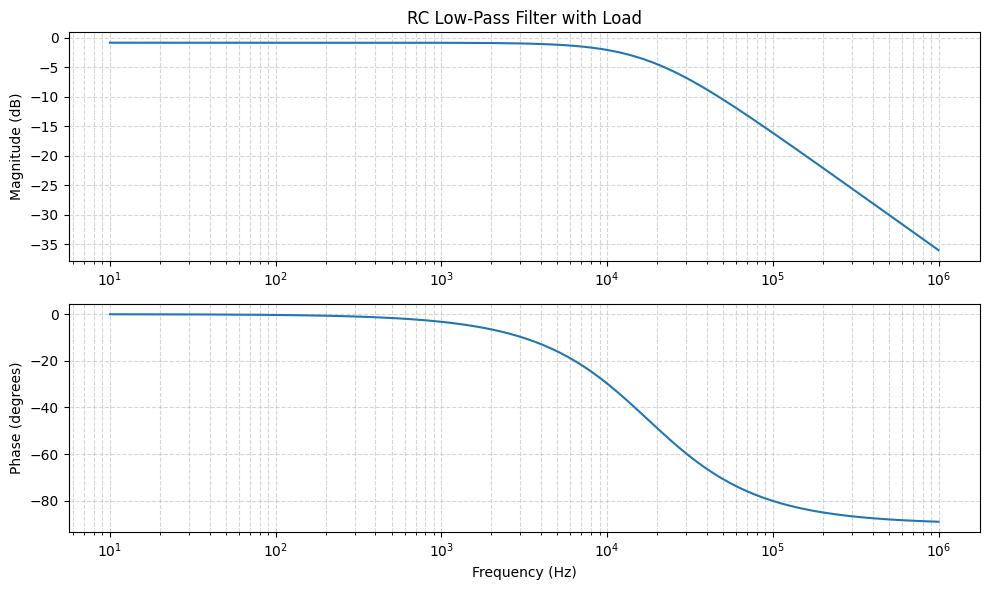

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Magnitude
plt.subplot(2, 1, 1)
plt.semilogx(frequencies, 20 * np.log10(Vout_mag))
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.ylabel("Magnitude (dB)")
plt.title("RC Low-Pass Filter with Load")

# Phase
plt.subplot(2, 1, 2)
plt.semilogx(frequencies, Vout_phase)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (degrees)")

plt.tight_layout()
plt.show()